In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
print(nav.columns.tolist())
print(perf.columns.tolist())
print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['date', 'index_name', 'close_value']


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


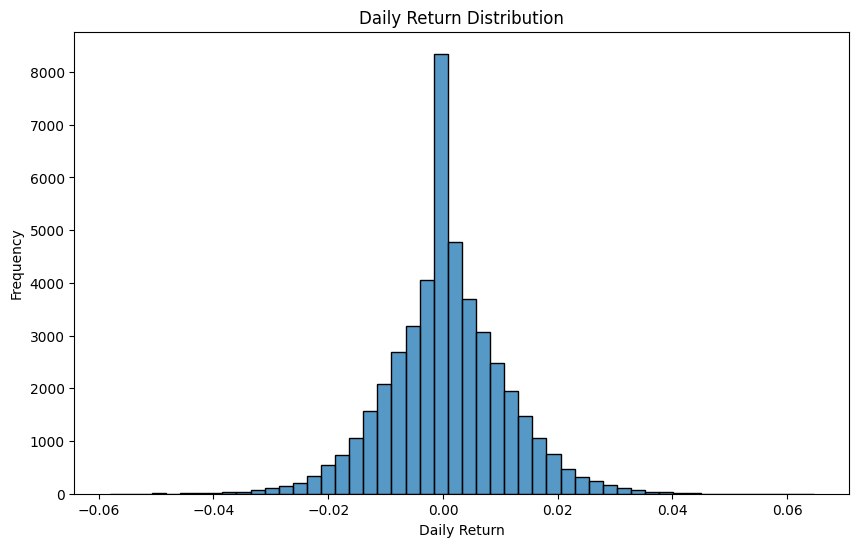

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [9]:
cagr_table = perf[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

cagr_table.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [10]:
cagr_table.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80
27,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
39,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61
38,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00
26,Axis Midcap Fund - Regular - Growth,14.88,15.18,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69


In [11]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [12]:
sharpe_rank = perf[
    ["scheme_name", "sharpe_ratio"]
].sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [13]:
sharpe_rank.to_csv(
    "../reports/sharpe_ranking.csv",
    index=False
)

In [14]:
sortino_rank = perf[
    ["scheme_name", "sortino_ratio"]
].sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_rank.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [15]:
alpha_beta = perf[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [16]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [17]:
drawdown_rank = perf[
    [
        "scheme_name",
        "max_drawdown_pct"
    ]
].sort_values(
    by="max_drawdown_pct"
)

drawdown_rank.head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [18]:
perf["return_rank"] = perf["return_3yr_pct"].rank(pct=True) * 100

perf["sharpe_rank"] = perf["sharpe_ratio"].rank(pct=True) * 100

perf["alpha_rank"] = perf["alpha"].rank(pct=True) * 100

perf["expense_rank"] = (
    100 - perf["expense_ratio_pct"].rank(pct=True) * 100
)

perf["dd_rank"] = (
    100 - perf["max_drawdown_pct"].rank(pct=True) * 100
)

perf["fund_score"] = (
    0.30 * perf["return_rank"] +
    0.25 * perf["sharpe_rank"] +
    0.20 * perf["alpha_rank"] +
    0.15 * perf["expense_rank"] +
    0.10 * perf["dd_rank"]
)

scorecard = perf[
    ["scheme_name", "fund_score"]
].sort_values(
    by="fund_score",
    ascending=False
)

scorecard.head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.1250
22,Kotak Flexicap Fund - Regular - Growth,70.8750
21,Kotak Emerging Equity Fund - Regular - Growth,69.8750
29,ABSL Small Cap Fund - Regular - Growth,67.6250
2,SBI Small Cap Fund - Regular Plan - Growth,63.7500
34,Mirae Asset Large Cap Fund - Regular - Growth,63.3125
9,HDFC Short Term Debt Fund - Regular - Growth,62.3750
14,ICICI Pru Liquid Fund - Regular - Growth,61.1250
12,ICICI Pru Midcap Fund - Regular - Growth,60.3750
11,ICICI Pru Bluechip Fund - Direct - Growth,59.0000


In [19]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [20]:
top5 = scorecard.head(5)

top5
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
